In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json

In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_rf_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Alcohol Consumption', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


In [3]:
X_train

,Age,Blood Pressure,Cholesterol Level,BMI,Alcohol Consumption,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,-0.289724,-0.779934,-0.356516,-0.825412,1.444308,-1.114622,1.505627,0.754065,0.200664,0.496829
1,-0.729079,1.609842,-1.206985,-0.108653,0.014929,-0.684668,-1.186045,1.305212,-0.480282,-0.229316
2,-1.058595,-1.348928,-0.977129,-1.205215,0.014929,-0.020423,-0.219804,0.796461,1.638189,-0.139948
3,1.687372,0.187356,-1.390870,0.137600,0.014929,-0.841466,-0.334833,-1.620108,-0.705019,1.498013
4,-1.168433,0.983948,-0.563387,-0.423572,-1.414450,-1.126689,1.459616,-1.111356,-1.290641,0.083695
...,...,...,...,...,...,...,...,...,...,...
8995,1.632453,-0.836833,-0.034717,1.521795,0.014929,-0.572279,1.298576,0.923649,-1.687643,0.425157
8996,0.094711,-1.235129,-1.505799,-0.612908,-1.414450,-0.132068,1.045512,1.432400,0.366204,1.013173
8997,-1.333191,0.130457,0.608881,-0.294138,0.014929,0.195343,-0.415353,1.093233,0.931737,1.156614
8998,-0.234805,-0.552336,-0.001949,1.475190,0.014929,-0.530117,1.252564,1.517192,-0.060651,0.493220


------------------------------
Baseline Model: Decision Tree (Pick Best Fold)
------------------------------
Cross-Validation Scores:
------------------------------
Fold 1: 0.7800  (78.00%)
Fold 2: 0.7728  (77.28%)


Fold 3: 0.7817  (78.17%)


Fold 4: 0.7694  (76.94%)
Fold 5: 0.7872  (78.72%)
------------------------------
>> Average CV Accuracy: 0.7782 (± 0.0064)
>> 🏆 Best Model from Fold: 5 (Score: 0.7872)
------------------------------

TEST SET PERFORMANCE (Using Model from Fold 5)
Accuracy:  0.7860
Precision: 0.1111
Recall:    0.0100
F1-Score:  0.0183
ROC-AUC:   0.5042
--------------------------------------------------
TP: 2, TN: 784, FP: 16, FN: 198


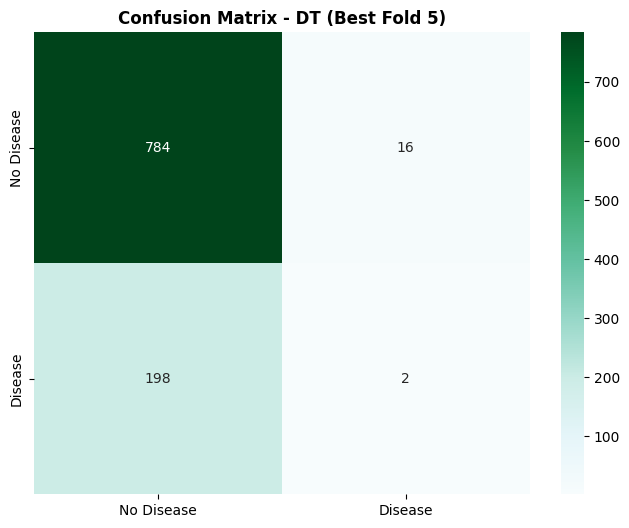

✓ Saved Best Model from Fold 5: decision_tree/models/DecisionTree_baseline_bestfold.pkl


In [4]:
print("-" * 30)
print('Baseline Model: Decision Tree (Pick Best Fold)')
print("-" * 30)

# กำหนดตัวแปรสำหรับเก็บโมเดลที่ดีที่สุด
best_model = None
best_score = 0
best_fold_idx = -1

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Cross-Validation Scores:")
print("-" * 30)

# วนลูป 5 รอบ
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # สร้างและเทรนโมเดลในรอบนั้น
    model = DecisionTreeClassifier(
        max_depth=10, min_samples_split=10, min_samples_leaf=5, 
        random_state=42, criterion='gini'
    )
    model.fit(X_fold_train, y_fold_train)
    
    # วัดผลกับ Validation Set ของรอบนั้น
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: {score:.4f}  ({score*100:.2f}%)")
    
    # ✅ เช็คว่ารอบนี้ดีกว่ารอบที่ผ่านมาไหม? ถ้าดีกว่า ให้เก็บไว้เป็น Best Model
    if score > best_score:
        best_score = score
        best_model = model # เก็บโมเดลตัวนี้ไว้
        best_fold_idx = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model from Fold: {best_fold_idx} (Score: {best_score:.4f})')
print("-" * 30)

# --- ใช้ Best Model ทำนาย Test Set ---
# (ไม่ต้อง fit ใหม่แล้ว ใช้ตัวที่เก็บมาได้เลย)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Get Confusion Matrix values
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (Using Model from Fold {best_fold_idx})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print("=" * 50)

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT (Best Fold {best_fold_idx})', fontweight='bold')
plt.show()

# Summary dictionary
dt_baseline_results = {
    'Model': 'Decision Tree',
    'Sampling': f'Baseline (Fold {best_fold_idx})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# Save Best Model
os.makedirs('decision_tree/models', exist_ok=True)
joblib.dump(best_model, 'decision_tree/models/DecisionTree_baseline_bestfold.pkl')
print(f"✓ Saved Best Model from Fold {best_fold_idx}: decision_tree/models/DecisionTree_baseline_bestfold.pkl")

------------------------------
Decision Tree + SMOTE (Pick Best Fold)
------------------------------
Cross-Validation Scores:
------------------------------
Fold 1: 0.4183  (41.83%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: 0.4272  (42.72%)
Fold 3: 0.3806  (38.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: 0.4450  (44.50%)
Fold 5: 0.4283  (42.83%)
------------------------------
>> Average CV Accuracy: 0.4199 (± 0.0215)
>> 🏆 Best Model from Fold: 4 (Score: 0.4450)
------------------------------

TEST SET PERFORMANCE (SMOTE - Best Fold 4)
Accuracy:  0.4500
Precision: 0.2064
Recall:    0.6150
F1-Score:  0.3090
ROC-AUC:   0.5133
--------------------------------------------------
TP: 123, TN: 327, FP: 473, FN: 77


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


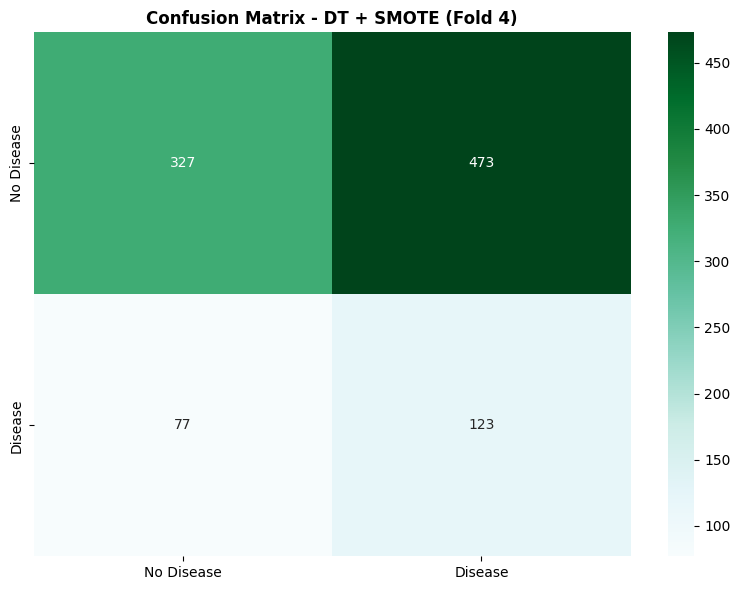

✓ Saved Best Model: decision_tree/models/DecisionTree_smote_bestfold.pkl


In [5]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('Decision Tree + SMOTE (Pick Best Fold)')
print("-" * 30)

# กำหนดตัวแปรสำหรับเก็บโมเดลที่ดีที่สุด
best_model_smote = None
best_score_smote = 0
best_fold_idx_smote = -1

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Cross-Validation Scores:")
print("-" * 30)

# วนลูป 5 รอบ
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # --- Apply SMOTE (เฉพาะ Training Set ในรอบนั้น) ---
    smote = SMOTE(random_state=42)
    X_fold_train_res, y_fold_train_res = smote.fit_resample(X_fold_train, y_fold_train)
    
    # สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, min_samples_split=10, min_samples_leaf=5, 
        random_state=42, criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # วัดผลกับ Validation Set (ที่ไม่ถูก SMOTE)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: {score:.4f}  ({score*100:.2f}%)")
    
    # ✅ เก็บโมเดลที่ดีที่สุด
    if score > best_score_smote:
        best_score_smote = score
        best_model_smote = model
        best_fold_idx_smote = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model from Fold: {best_fold_idx_smote} (Score: {best_score_smote:.4f})')
print("-" * 30)

# --- ใช้ Best Model ทำนาย Test Set ---
y_pred = best_model_smote.predict(X_test)
y_pred_proba = best_model_smote.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- ดึงค่า TP, TN, FP, FN ---
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (SMOTE - Best Fold {best_fold_idx_smote})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print("=" * 50)

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + SMOTE (Fold {best_fold_idx_smote})', fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree/models/cm_dt_smote.png', dpi=300) # บันทึกรูป
plt.show()

# Summary dictionary
dt_smote_results = {
    'Model': 'Decision Tree',
    'Sampling': f'SMOTE (Fold {best_fold_idx_smote})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# Save Best Model
joblib.dump(best_model_smote, 'decision_tree/models/DecisionTree_smote_bestfold.pkl')
# Save Sampler (อันนี้ต้องระวังเพราะเราสร้างใหม่ทุกรอบ ถ้าจะเก็บต้องเก็บของรอบ Best Fold)
# แต่ปกติเราไม่ได้ใช้ Sampler ตอน Test, ใช้แค่ Model ก็พอครับ
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_smote_bestfold.pkl")

------------------------------
Decision Tree + ADASYN (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.4283 (42.83%)
Fold 2: Val Accuracy = 0.4444 (44.44%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 3: Val Accuracy = 0.3733 (37.33%)
Fold 4: Val Accuracy = 0.4339 (43.39%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.4556 (45.56%)
------------------------------
>> Average CV Accuracy: 0.4271 (± 0.0285)
>> 🏆 Best Model Found in Fold: 5 (Score: 0.4556)
------------------------------

TEST SET PERFORMANCE (ADASYN - Model from Fold 5)
Accuracy:  0.4460
Precision: 0.1980
Recall:    0.5800
F1-Score:  0.2952
ROC-AUC:   0.5041
--------------------------------------------------
TP (เจอคนป่วยจริง): 116
TN (เจอคนปกติจริง): 330
FP (ทายป่วยผิด):    470
FN (หลุดคนป่วย):    84  <-- ค่านี้ยิ่งน้อยยิ่งดี


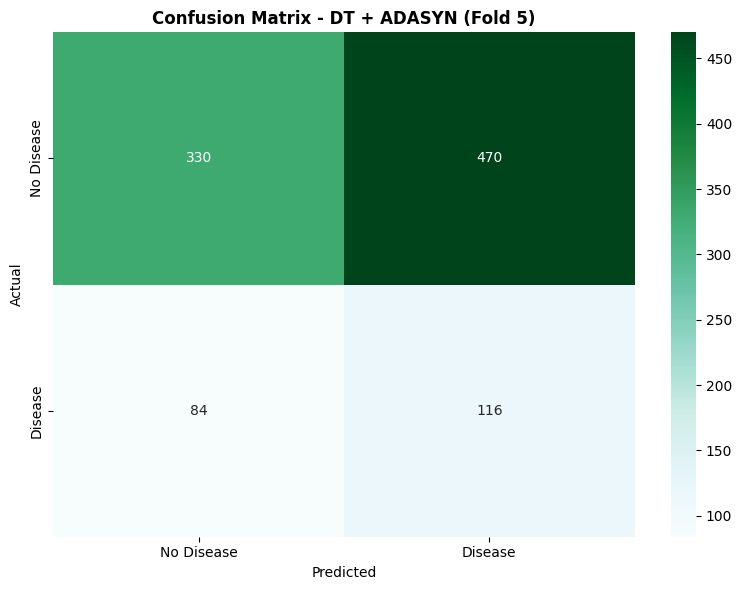

✓ Saved Best Model: decision_tree/models/DecisionTree_adasyn_bestfold.pkl


In [6]:
from imblearn.over_sampling import ADASYN
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร
# ==========================================
print("-" * 30)
print('Decision Tree + ADASYN (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ" (Best Model)
best_model_adasyn = None       # เก็บตัวโมเดล
best_score_adasyn = 0          # เก็บสะแนนที่สูงที่สุดที่เคยทำได้
best_fold_idx_adasyn = -1      # เก็บว่ารอบที่เท่าไหร่คือรอบที่ดีที่สุด

# สร้างตัวแบ่งข้อมูล (Cross-Validator)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
# split(X_train, y_train) จะแบ่งข้อมูลเป็น Train/Val ให้เราอัตโนมัติ 5 รูปแบบ
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index ที่แบ่งไว้
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ ADASYN (สำคัญ! ทำเฉพาะ Training Set เท่านั้น)
    # ADASYN จะสร้างข้อมูลเทียมตรงจุดที่ Class น้อยทับซ้อนกับ Class มาก (จุดที่แยกยากๆ)
    adasyn = ADASYN(random_state=42)
    X_fold_train_res, y_fold_train_res = adasyn.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res) # สอนด้วยข้อมูลที่ ADASYN แล้ว
    
    # 2.4 สอบย่อย (Validate) กับข้อมูลจริงที่ไม่เคยเห็น (Validation Set)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ (Pick Best Fold)
    # ถ้ารอบนี้คะแนนดีกว่าสถิติเก่า -> อัปเดตให้เป็นที่ 1 คนใหม่
    if score > best_score_adasyn:
        best_score_adasyn = score
        best_model_adasyn = model
        best_fold_idx_adasyn = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_adasyn} (Score: {best_score_adasyn:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุด (best_model_adasyn) มาทำนายข้อมูล Test Set (สนามสอบจริง)
y_pred = best_model_adasyn.predict(X_test)
y_pred_proba = best_model_adasyn.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติทั้งหมด
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# 🔥 เจาะลึก Confusion Matrix (TP, TN, FP, FN)
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel() # ระเบิดค่าออกมา 4 ตัว

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (ADASYN - Model from Fold {best_fold_idx_adasyn})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}  <-- ค่านี้ยิ่งน้อยยิ่งดี")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + ADASYN (Fold {best_fold_idx_adasyn})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_adasyn.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary (เพื่อเอาไปรวมตารางตอนท้าย)
dt_adasyn_results = {
    'Model': 'Decision Tree',
    'Sampling': f'ADASYN (Fold {best_fold_idx_adasyn})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน (.pkl)
joblib.dump(best_model_adasyn, 'decision_tree/models/DecisionTree_adasyn_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_adasyn_bestfold.pkl")

------------------------------
Decision Tree + RandomUnderSampler (Pick Best Fold)
------------------------------
Fold 1: Val Accuracy = 0.4539
Fold 2: Val Accuracy = 0.4783
Fold 3: Val Accuracy = 0.5339
Fold 4: Val Accuracy = 0.5550
Fold 5: Val Accuracy = 0.6556
------------------------------
>> Average CV Accuracy: 0.5353
>> 🏆 Best Model Found in Fold: 5

TEST PERFORMANCE (RUS - Fold 5)
Recall (Sensitive): 0.2150
FN (Missed Cases): 157


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

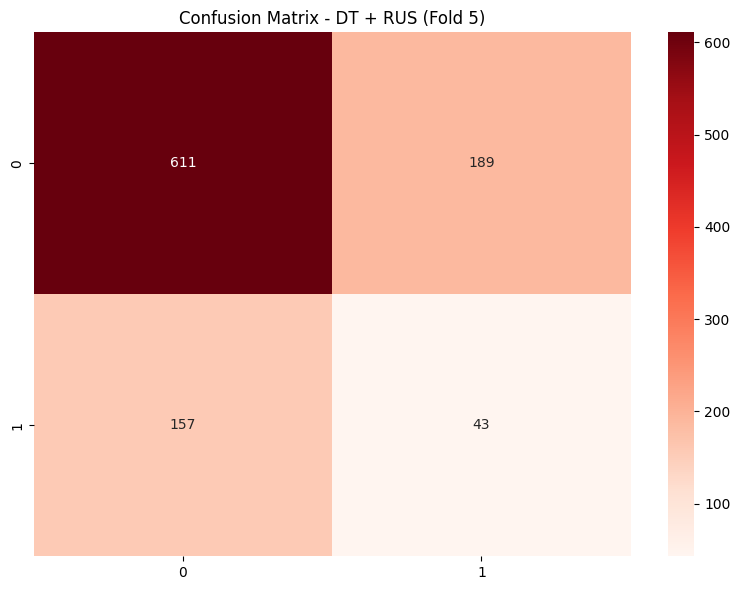

['decision_tree/models/DecisionTree_rus_bestfold.pkl']

In [7]:
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่า (RandomUnderSampler)
# ==========================================
print("-" * 30)
print('Decision Tree + RandomUnderSampler (Pick Best Fold)')
print("-" * 30)

best_model_rus = None
best_score_rus = 0
best_fold_idx_rus = -1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# ==========================================
# 🔄 ส่วนที่ 2: Training Loop
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ใช้ RandomUnderSampler
    rus = RandomUnderSampler(random_state=42)
    X_fold_train_res, y_fold_train_res = rus.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดล
    model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, criterion='gini')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 Validate
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_rus:
        best_score_rus = score
        best_model_rus = model
        best_fold_idx_rus = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f}')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_rus}')

# ==========================================
# 📊 ส่วนที่ 3: Test Set Evaluation
# ==========================================
y_pred = best_model_rus.predict(X_test)
y_pred_proba = best_model_rus.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (RUS - Fold {best_fold_idx_rus})")
print(f"Recall (Sensitive): {test_recall:.4f}")
print(f"FN (Missed Cases): {fn}")

# ==========================================
# 🎨 ส่วนที่ 4: Save Results
# ==========================================
# Plot Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix - DT + RUS (Fold {best_fold_idx_rus})')
plt.tight_layout()
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_rus.png', dpi=300)
plt.show()

# Save Result Dict
dt_rus_results = {
    'Model': 'Decision Tree',
    'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_rus})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# Save Model
joblib.dump(best_model_rus, 'decision_tree/models/DecisionTree_rus_bestfold.pkl')

------------------------------
Decision Tree + NearMiss (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------
Fold 1: Val Accuracy = 0.5272 (52.72%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5606 (56.06%)
Fold 3: Val Accuracy = 0.5250 (52.50%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5378 (53.78%)
Fold 5: Val Accuracy = 0.5150 (51.50%)
------------------------------
>> Average CV Accuracy: 0.5331 (± 0.0155)
>> 🏆 Best Model Found in Fold: 2 (Score: 0.5606)
------------------------------

TEST SET PERFORMANCE (NearMiss - Model from Fold 2)
Accuracy:  0.5580
Precision: 0.2160
Recall:    0.4600
F1-Score:  0.2939
ROC-AUC:   0.5449
--------------------------------------------------
TP (เจอคนป่วยจริง): 92
TN (เจอคนปกติจริง): 466
FP (ทายป่วยผิด):    334
FN (หลุดคนป่วย):    108


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


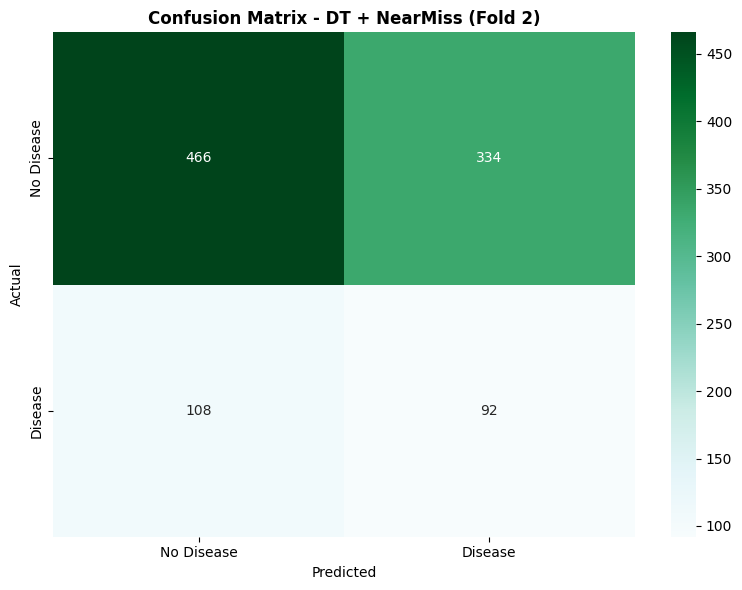

✓ Saved Best Model: decision_tree/models/DecisionTree_nearmiss_bestfold.pkl


In [8]:
from imblearn.under_sampling import NearMiss
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (NearMiss)
# ==========================================
print("-" * 30)
print('Decision Tree + NearMiss (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_nearmiss = None     
best_score_nearmiss = 0        
best_fold_idx_nearmiss = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ NearMiss
    # version=1 (Default) : เลือก Majority ที่อยู่ใกล้ Minority ที่สุด 3 จุดเฉลี่ย
    nm = NearMiss(version=1) 
    X_fold_train_res, y_fold_train_res = nm.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_nearmiss:
        best_score_nearmiss = score
        best_model_nearmiss = model
        best_fold_idx_nearmiss = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_nearmiss} (Score: {best_score_nearmiss:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_nearmiss.predict(X_test)
y_pred_proba = best_model_nearmiss.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (NearMiss - Model from Fold {best_fold_idx_nearmiss})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + NearMiss (Fold {best_fold_idx_nearmiss})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_nearmiss.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_nearmiss_results = {
    'Model': 'Decision Tree',
    'Sampling': f'NearMiss (Fold {best_fold_idx_nearmiss})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_nearmiss, 'decision_tree/models/DecisionTree_nearmiss_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_nearmiss_bestfold.pkl")

------------------------------
Decision Tree + ClusterCentroids (Pick Best Fold)
------------------------------
Start Cross-Validation...
(Warning: ClusterCentroids might take a while due to clustering calculation...)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.6117 (61.17%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5617 (56.17%)


...

Fold 3: Val Accuracy = 0.5528 (55.28%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5944 (59.44%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5494 (54.94%)
------------------------------
>> Average CV Accuracy: 0.5740 (± 0.0247)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.6117)
------------------------------

TEST SET PERFORMANCE (ClusterCentroids - Model from Fold 1)
Accuracy:  0.5980
Precision: 0.1958
Recall:    0.3250
F1-Score:  0.2444
ROC-AUC:   0.4950
--------------------------------------------------
TP (เจอคนป่วยจริง): 65
TN (เจอคนปกติจริง): 533
FP (ทายป่วยผิด):    267
FN (หลุดคนป่วย):    135


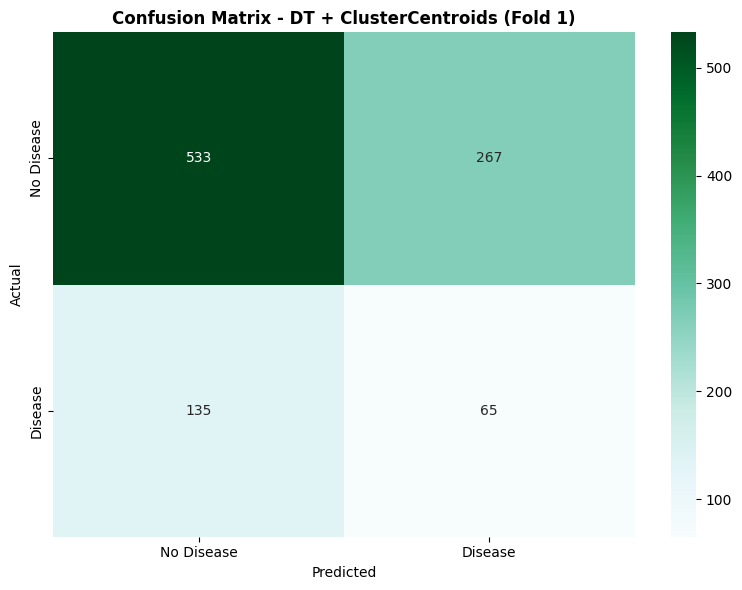

✓ Saved Best Model: decision_tree/models/DecisionTree_cc_bestfold.pkl


In [9]:
from imblearn.under_sampling import ClusterCentroids
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (ClusterCentroids)
# ==========================================
print("-" * 30)
print('Decision Tree + ClusterCentroids (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_cc = None     
best_score_cc = 0        
best_fold_idx_cc = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("(Warning: ClusterCentroids might take a while due to clustering calculation...)")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ ClusterCentroids
    # แทนที่จะสุ่มลบ จะใช้การยุบรวมกลุ่มข้อมูลให้เหลือแค่จุดกึ่งกลาง (Centroid)
    cc = ClusterCentroids(random_state=42) 
    X_fold_train_res, y_fold_train_res = cc.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_cc:
        best_score_cc = score
        best_model_cc = model
        best_fold_idx_cc = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_cc} (Score: {best_score_cc:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_cc.predict(X_test)
y_pred_proba = best_model_cc.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (ClusterCentroids - Model from Fold {best_fold_idx_cc})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + ClusterCentroids (Fold {best_fold_idx_cc})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_cc.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_cc_results = {
    'Model': 'Decision Tree',
    'Sampling': f'ClusterCentroids (Fold {best_fold_idx_cc})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_cc, 'decision_tree/models/DecisionTree_cc_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_cc_bestfold.pkl")

------------------------------
Decision Tree + SMOTETomek (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.4444 (44.44%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.4100 (41.00%)


...

Fold 3: Val Accuracy = 0.3933 (39.33%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.4517 (45.17%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.4172 (41.72%)
------------------------------
>> Average CV Accuracy: 0.4233 (± 0.0217)
>> 🏆 Best Model Found in Fold: 4 (Score: 0.4517)
------------------------------

TEST SET PERFORMANCE (SMOTETomek - Model from Fold 4)
Accuracy:  0.4680
Precision: 0.2057
Recall:    0.5800
F1-Score:  0.3037
ROC-AUC:   0.5140
--------------------------------------------------
TP (เจอคนป่วยจริง): 116
TN (เจอคนปกติจริง): 352
FP (ทายป่วยผิด):    448
FN (หลุดคนป่วย):    84


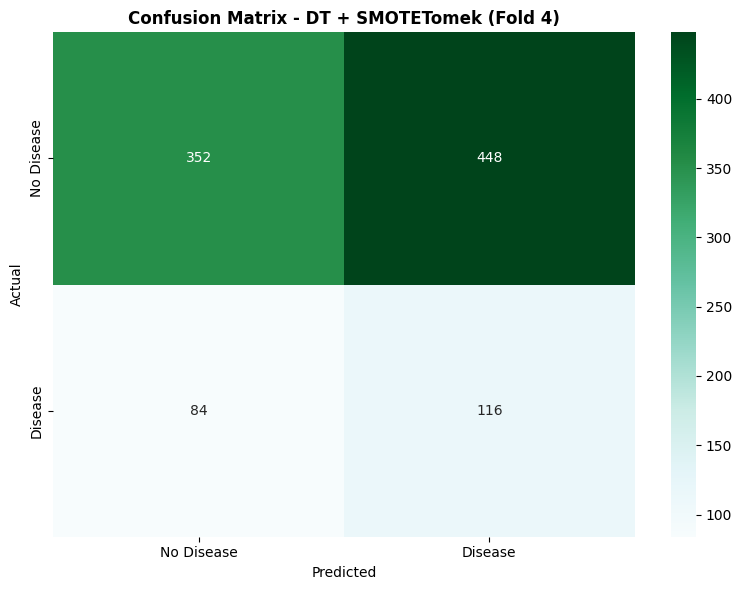

✓ Saved Best Model: decision_tree/models/DecisionTree_smotetomek_bestfold.pkl


In [10]:
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (SMOTETomek)
# ==========================================
print("-" * 30)
print('Decision Tree + SMOTETomek (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_smt = None     
best_score_smt = 0        
best_fold_idx_smt = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ SMOTETomek
    # (สร้างเพิ่มด้วย SMOTE แล้วตัดขอบด้วย Tomek Links)
    smt = SMOTETomek(random_state=42) 
    X_fold_train_res, y_fold_train_res = smt.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_smt:
        best_score_smt = score
        best_model_smt = model
        best_fold_idx_smt = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_smt} (Score: {best_score_smt:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_smt.predict(X_test)
y_pred_proba = best_model_smt.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (SMOTETomek - Model from Fold {best_fold_idx_smt})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + SMOTETomek (Fold {best_fold_idx_smt})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_smotetomek.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_smt_results = {
    'Model': 'Decision Tree',
    'Sampling': f'SMOTETomek (Fold {best_fold_idx_smt})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_smt, 'decision_tree/models/DecisionTree_smotetomek_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_smotetomek_bestfold.pkl")

------------------------------
Decision Tree + SMOTEENN (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.3222 (32.22%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.3111 (31.11%)


...

Fold 3: Val Accuracy = 0.3256 (32.56%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.3417 (34.17%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.3572 (35.72%)
------------------------------
>> Average CV Accuracy: 0.3316 (± 0.0161)
>> 🏆 Best Model Found in Fold: 5 (Score: 0.3572)
------------------------------

TEST SET PERFORMANCE (SMOTEENN - Model from Fold 5)
Accuracy:  0.3260
Precision: 0.1873
Recall:    0.7100
F1-Score:  0.2965
ROC-AUC:   0.4470
--------------------------------------------------
TP (เจอคนป่วยจริง): 142
TN (เจอคนปกติจริง): 184
FP (ทายป่วยผิด):    616
FN (หลุดคนป่วย):    58


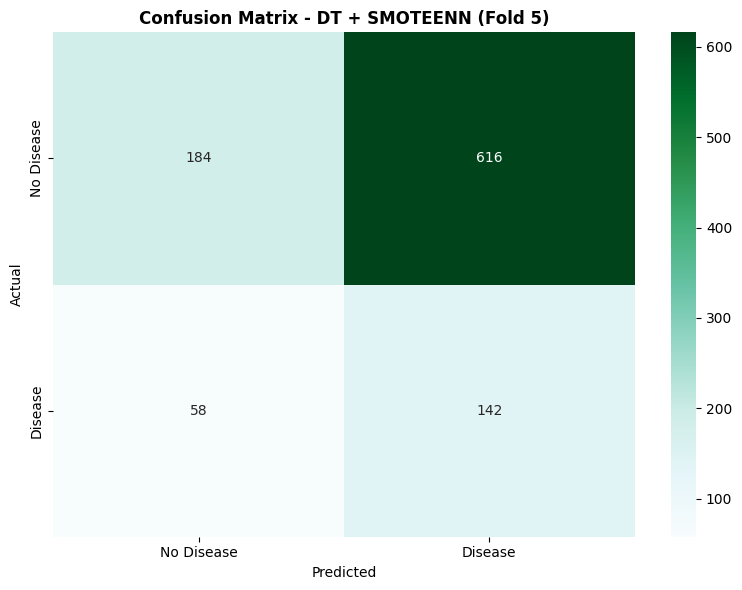

✓ Saved Best Model: decision_tree/models/DecisionTree_smoteenn_bestfold.pkl


In [11]:
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (SMOTEENN)
# ==========================================
print("-" * 30)
print('Decision Tree + SMOTEENN (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_sme = None     
best_score_sme = 0        
best_fold_idx_sme = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ SMOTEENN
    # (เพิ่มด้วย SMOTE แล้วลบ Noise แบบเข้มข้นด้วย ENN)
    sme = SMOTEENN(random_state=42) 
    X_fold_train_res, y_fold_train_res = sme.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_sme:
        best_score_sme = score
        best_model_sme = model
        best_fold_idx_sme = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_sme} (Score: {best_score_sme:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_sme.predict(X_test)
y_pred_proba = best_model_sme.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (SMOTEENN - Model from Fold {best_fold_idx_sme})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + SMOTEENN (Fold {best_fold_idx_sme})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_smoteenn.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_sme_results = {
    'Model': 'Decision Tree',
    'Sampling': f'SMOTEENN (Fold {best_fold_idx_sme})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_sme, 'decision_tree/models/DecisionTree_smoteenn_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_smoteenn_bestfold.pkl")

------------------------------
Decision Tree + ADASYN + Tomek Links (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.4294 (42.94%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.4461 (44.61%)


...

Fold 3: Val Accuracy = 0.3706 (37.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.4272 (42.72%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.4544 (45.44%)
------------------------------
>> Average CV Accuracy: 0.4256 (± 0.0293)
>> 🏆 Best Model Found in Fold: 5 (Score: 0.4544)
------------------------------

TEST SET PERFORMANCE (ADASYN + Tomek - Model from Fold 5)
Accuracy:  0.4460
Precision: 0.1980
Recall:    0.5800
F1-Score:  0.2952
ROC-AUC:   0.5015
--------------------------------------------------
TP (เจอคนป่วยจริง): 116
TN (เจอคนปกติจริง): 330
FP (ทายป่วยผิด):    470
FN (หลุดคนป่วย):    84


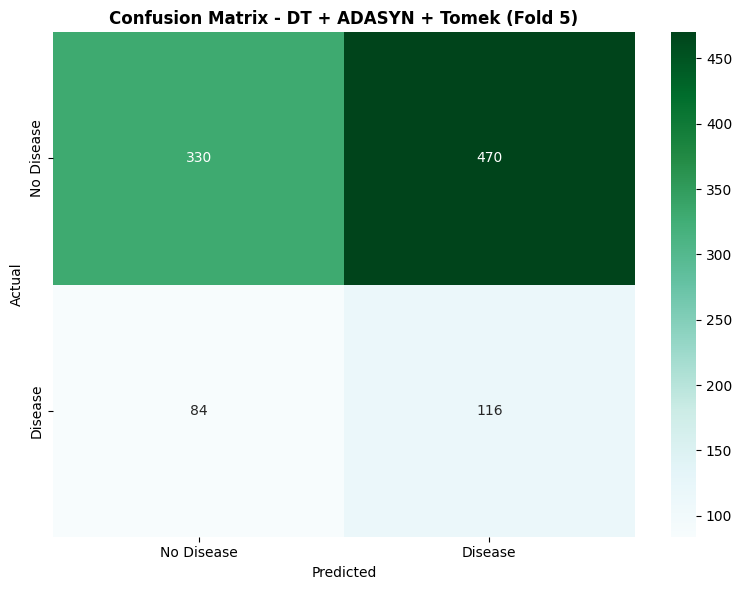

✓ Saved Best Model: decision_tree/models/DecisionTree_adasyn_tomek_bestfold.pkl


In [12]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (ADASYN + Tomek)
# ==========================================
print("-" * 30)
print('Decision Tree + ADASYN + Tomek Links (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_ada_tomek = None     
best_score_ada_tomek = 0        
best_fold_idx_ada_tomek = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้แบบ Pipeline (ทำทีละขั้น)
    # Step 1: ADASYN (สร้างข้อมูลเทียมเน้นจุดยาก)
    ada = ADASYN(random_state=42)
    X_res_step1, y_res_step1 = ada.fit_resample(X_fold_train, y_fold_train)
    
    # Step 2: Tomek Links (ลบตัวที่อยู่ใกล้กันเกินไป เพื่อให้ขอบชัดขึ้น)
    # ใช้ข้อมูลจาก Step 1 มาทำต่อ
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res_step1, y_res_step1)
    
    # 2.3 สร้างและเทรนโมเดล (ใช้ข้อมูลจาก Step 2)
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_ada_tomek:
        best_score_ada_tomek = score
        best_model_ada_tomek = model
        best_fold_idx_ada_tomek = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_ada_tomek} (Score: {best_score_ada_tomek:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_ada_tomek.predict(X_test)
y_pred_proba = best_model_ada_tomek.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (ADASYN + Tomek - Model from Fold {best_fold_idx_ada_tomek})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + ADASYN + Tomek (Fold {best_fold_idx_ada_tomek})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_adasyn_tomek.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_ada_tomek_results = {
    'Model': 'Decision Tree',
    'Sampling': f'ADASYN + Tomek (Fold {best_fold_idx_ada_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_ada_tomek, 'decision_tree/models/DecisionTree_adasyn_tomek_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_adasyn_tomek_bestfold.pkl")

------------------------------
Decision Tree + Borderline SMOTE v.2 + Tomek (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.2800 (28.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.2650 (26.50%)


...

Fold 3: Val Accuracy = 0.3033 (30.33%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.3328 (33.28%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.2872 (28.72%)
------------------------------
>> Average CV Accuracy: 0.2937 (± 0.0231)
>> 🏆 Best Model Found in Fold: 4 (Score: 0.3328)
------------------------------

TEST SET PERFORMANCE (Borderline-2 + Tomek - Model from Fold 4)
Accuracy:  0.3260
Precision: 0.1985
Recall:    0.7800
F1-Score:  0.3164
ROC-AUC:   0.4942
--------------------------------------------------
TP (เจอคนป่วยจริง): 156
TN (เจอคนปกติจริง): 170
FP (ทายป่วยผิด):    630
FN (หลุดคนป่วย):    44


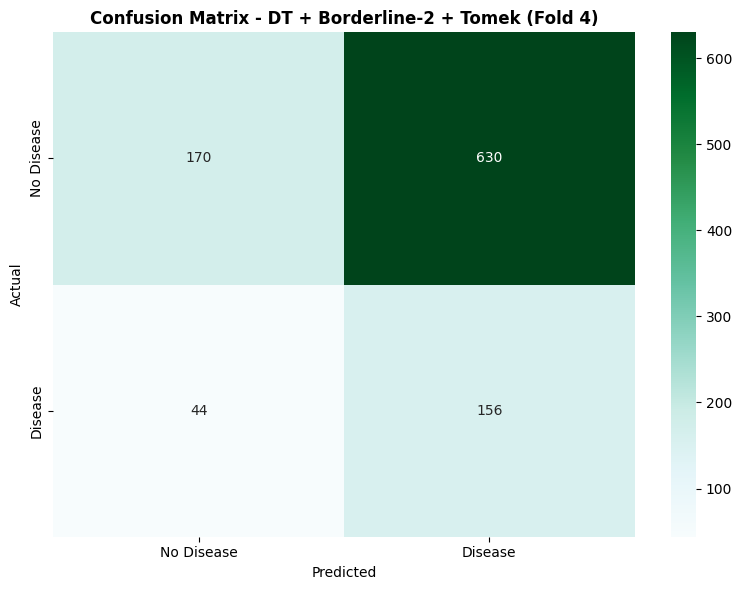

✓ Saved Best Model: decision_tree/models/DecisionTree_borderline2_tomek_bestfold.pkl


In [13]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (Borderline-2 + Tomek)
# ==========================================
print("-" * 30)
print('Decision Tree + Borderline SMOTE v.2 + Tomek (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรไว้เก็บ "ผู้ชนะ"
best_model_bl_tomek = None     
best_score_bl_tomek = 0        
best_fold_idx_bl_tomek = -1    

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้แบบ Pipeline
    # Step 1: Borderline SMOTE v.2 (เน้นขอบ + ดูเพื่อนบ้านต่างสี)
    # kind='borderline-2' คือคีย์สำคัญตรงนี้
    bl_smote = BorderlineSMOTE(kind='borderline-2', random_state=42)
    X_res_step1, y_res_step1 = bl_smote.fit_resample(X_fold_train, y_fold_train)
    
    # Step 2: Tomek Links (คลีนพื้นที่ทับซ้อน)
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res_step1, y_res_step1)
    
    # 2.3 สร้างและเทรนโมเดล
    model = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        criterion='gini'
    )
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 สอบย่อย (Validate)
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f} ({score*100:.2f}%)")
    
    # 2.5 คัดเลือกผู้ชนะ
    if score > best_score_bl_tomek:
        best_score_bl_tomek = score
        best_model_bl_tomek = model
        best_fold_idx_bl_tomek = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_bl_tomek} (Score: {best_score_bl_tomek:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred = best_model_bl_tomek.predict(X_test)
y_pred_proba = best_model_bl_tomek.predict_proba(X_test)[:, 1]

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (Borderline-2 + Tomek - Model from Fold {best_fold_idx_bl_tomek})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP (เจอคนป่วยจริง): {tp}")
print(f"TN (เจอคนปกติจริง): {tn}")
print(f"FP (ทายป่วยผิด):    {fp}")
print(f"FN (หลุดคนป่วย):    {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: สร้างกราฟและบันทึกผล
# ==========================================
# 4.1 พลอตกราฟ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - DT + Borderline-2 + Tomek (Fold {best_fold_idx_bl_tomek})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# บันทึกรูป
os.makedirs('decision_tree/models', exist_ok=True)
plt.savefig('decision_tree/models/cm_dt_borderline2_tomek.png', dpi=300)
plt.show()

# 4.2 เก็บผลลัพธ์ลง Dictionary
dt_bl_tomek_results = {
    'Model': 'Decision Tree',
    'Sampling': f'Borderline-2 + Tomek (Fold {best_fold_idx_bl_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 
    'TN': tn, 
    'FP': fp, 
    'FN': fn
}

# 4.3 บันทึกโมเดลเก็บไว้ใช้งาน
joblib.dump(best_model_bl_tomek, 'decision_tree/models/DecisionTree_borderline2_tomek_bestfold.pkl')
print(f"✓ Saved Best Model: decision_tree/models/DecisionTree_borderline2_tomek_bestfold.pkl")

🏆 FINAL COMPARISON TABLE (Sorted by Recall)


,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,TN,FP,FN
0,Decision Tree,Borderline-2 + Tomek (Fold 4),0.293667,0.023122,0.326,0.198473,0.780,0.316430,0.494238,156,170,630,44
1,Decision Tree,SMOTEENN (Fold 5),0.331556,0.016138,0.326,0.187335,0.710,0.296451,0.446997,142,184,616,58
2,Decision Tree,SMOTE (Fold 4),0.419889,0.021472,0.450,0.206376,0.615,0.309045,0.513256,123,327,473,77
3,Decision Tree,ADASYN (Fold 5),0.427111,0.028457,0.446,0.197952,0.580,0.295165,0.504100,116,330,470,84
4,Decision Tree,SMOTETomek (Fold 4),0.423333,0.021742,0.468,0.205674,0.580,0.303665,0.513997,116,352,448,84
5,Decision Tree,ADASYN + Tomek (Fold 5),0.425556,0.029326,0.446,0.197952,0.580,0.295165,0.501481,116,330,470,84
6,Decision Tree,NearMiss (Fold 2),0.533111,0.015514,0.558,0.215962,0.460,0.293930,0.544900,92,466,334,108
7,Decision Tree,ClusterCentroids (Fold 1),0.574000,0.024667,0.598,0.195783,0.325,0.244361,0.495019,65,533,267,135
8,Decision Tree,RandomUnderSampler (Fold 5),0.535333,0.070320,0.654,0.185345,0.215,0.199074,0.492578,43,611,189,157
9,Decision Tree,Baseline (Fold 5),0.778222,0.006367,0.786,0.111111,0.010,0.018349,0.504231,2,784,16,198



✓ Saved comparison table to: decision_tree/imbalance_technique_comparison.csv


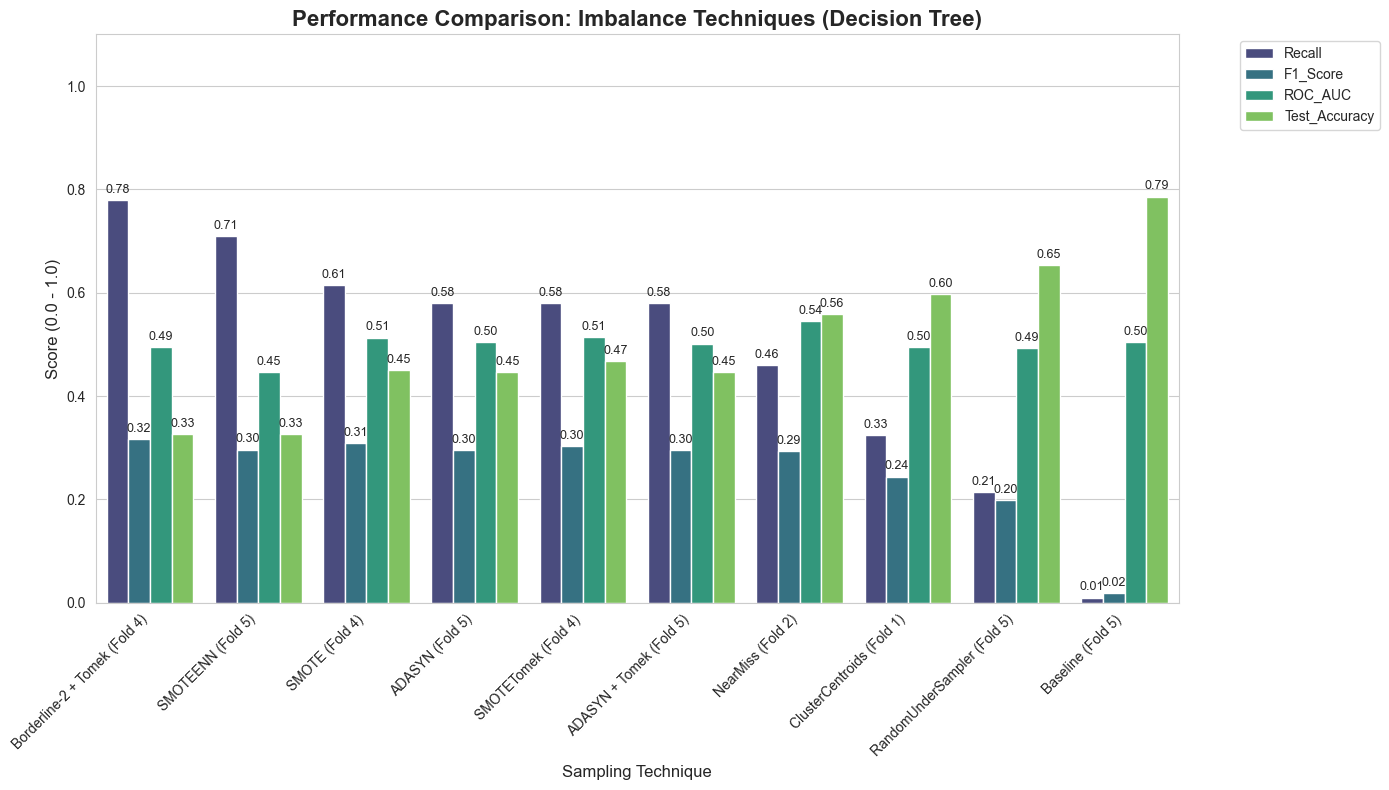

In [14]:
import pandas as pd
from IPython.display import display

# 1. รวม Dictionary ผลลัพธ์ทั้งหมดเข้าใน List เดียว
# (ต้องรันโค้ดก่อนหน้านี้ให้ครบทุกตัวแปรนะคะ ไม่งั้นจะ Error ว่าหาตัวแปรไม่เจอ)
all_results = [
    dt_baseline_results,
    dt_smote_results,
    dt_adasyn_results,
    dt_rus_results,
    dt_nearmiss_results,
    dt_cc_results,
    dt_smt_results,
    dt_sme_results,
    dt_ada_tomek_results,
    dt_bl_tomek_results
]

# 2. แปลงเป็น DataFrame
df_results = pd.DataFrame(all_results)

# 3. จัดเรียงลำดับ (Sort)
# ข้อมูลการแพทย์เราเน้น Recall (หาคนป่วยให้เจอ) และ ROC_AUC
# เรียงจากมากไปน้อย
df_results = df_results.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# 4. แสดงผล
print("=" * 80)
print("🏆 FINAL COMPARISON TABLE (Sorted by Recall)")
print("=" * 80)
display(df_results) # ถ้าใช้ Jupyter Notebook ใช้คำสั่งนี้จะสวยกว่า print()

# 5. บันทึกเป็นไฟล์ CSV
df_results.to_csv('decision_tree/imbalance_technique_comparison.csv', index=False)
print(f"\n✓ Saved comparison table to: decision_tree/imbalance_technique_comparison.csv")

# ปรับแต่งกราฟ
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# แปลงข้อมูลให้อยู่ในรูปแบบที่พลอตง่าย (Melt)
metrics_to_plot = ['Recall', 'F1_Score', 'ROC_AUC', 'Test_Accuracy']
df_melted = df_results.melt(id_vars='Sampling', value_vars=metrics_to_plot, 
                            var_name='Metric', value_name='Score')

# สร้าง Bar Plot
ax = sns.barplot(data=df_melted, x='Sampling', y='Score', hue='Metric', palette='viridis')

# ตกแต่ง
plt.title('Performance Comparison: Imbalance Techniques (Decision Tree)', fontsize=16, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Sampling Technique', fontsize=12)
plt.xticks(rotation=45, ha='right') # เอียงชื่อแกน X ให้อ่านง่าย
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # เอา Legend ไปไว้ข้างนอก
plt.ylim(0, 1.1)

# ใส่ตัวเลขบนแท่งกราฟ
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('decision_tree/models/technique_comparison_chart.png', dpi=300)
plt.show()